# 02 Applies both K-Means and hierarchical clustering on P and Q features extracted from the selected dataset.

Three datasets are available via the `dataset_chosen` key:

| key | description |
|---|---|
|`Slovakia`| Slovakian dataset with 1000 buildings measured in 2016|
|`Germany`| German dataset with 38 buildings measured from 2018 till 2020|
|`USA`| MFRED (USA) dataset with 26 buildings measured from 2019 till 2021|

> **Note:** The file can be manually followed sequentially to train or test the clustering methods.

In [217]:
import numpy as np
from pathlib import Path
import importlib
import pandas as pd

import sys
sys.path.append("..")

## 2.1 Selecting the input parameters.

In order to consider different scenarios, the relevant input parameters are given selected via their respective keys.

| keys | values | description |
|---|---|---|
|`dataset_chosen`|`Slovakia`, `Germany`, `USA`| Selects the dataset on which to do the analysis.|
|`trainVsTest`| `Train`, `Test`| Trains or tests the clustering algorithm.|
|`MAEVsRMSE`| `MAE`, `RMSE`| Uses MAE or RMSE metric|
|`Clustering_method`|`KMeans`, `hierarchical`| Selects between K-Means or hierarchical clustering.|
|`input_period`|`year`, `month`, `seasonal`| Selects the input period to consider.|
|`resolution`|`15_min`, `hourly`, `daily`| Selects the resolution to consider.|
|`PearsonVsPCA`| `Pearson`, `PCA`| Uses Pearson or PCA to reduce feature set.|

> **Note:** The input periods to select from consider the full year (`year`) of data, consider the most representative month (`month`) of data, or consider each full season separately (`seasonal`).

In [ ]:
dataset_chosen = "USA"
trainVsTest = "Test"
MAEVsRMSE = "RMSE"
Clustering_method = "hierarchical"
input_period = "seasonal"
resolution = "15_min"
PearsonVsPCA = "PCA"

## 2.2 Loading in the cleaned data.

In [250]:
import general_clustering_functions as gcf
project_root = Path().resolve()

if dataset_chosen == "Slovakia":
    path_folder = project_root / "data" / "repository" / "Slovakia"
elif dataset_chosen == "Germany":
    path_folder = project_root / "data" / "repository" / "Germany"
elif dataset_chosen == "USA":
    path_folder = project_root / "data" / "repository" / "USA"

if trainVsTest == "Train":
    power_dict, houses = gcf.loading_cleaned_files(path_folder, "power_dict_train.zip", dataset_chosen)
elif trainVsTest == "Test":
    power_dict, houses = gcf.loading_cleaned_files(path_folder, "power_dict_test.zip", dataset_chosen)

if PearsonVsPCA == "PCA":
    power_dict_train, houses_train = gcf.loading_cleaned_files(path_folder, "power_dict_train.zip", dataset_chosen)
    
print(power_dict[list(power_dict.keys())[0]].head())

Error removing C:\Users\u0181580\OneDrive - KU Leuven\PHD\Julia\clean_code_thesis\clustering\data\repository\USA\extracted_dataframes: (<class 'PermissionError'>, PermissionError(13, 'Toegang geweigerd'), <traceback object at 0x000001D305980CC0>)
                           Nr       P       Q         S        PF  PV
DateTimeUTC                                                          
2021-01-01 00:00:00-05:00   1  0.0229  0.0039  0.023230  0.985806   0
2021-01-01 00:15:00-05:00   1  0.0378  0.0120  0.039659  0.953124   0
2021-01-01 00:30:00-05:00   1  0.0267  0.0003  0.026702  0.999937   0
2021-01-01 00:45:00-05:00   1  0.0256  0.0027  0.025742  0.994484   0
2021-01-01 01:00:00-05:00   1  0.0349  0.0053  0.035300  0.988665   0


## 2.3 Calculate the base case accuracy for the given dataset

In [251]:
best_PF, basecase = gcf.basecase(power_dict, MAEVsRMSE)
print(f"Best PF: {best_PF}, Basecase error: {basecase}")

[0.32044, 0.3085, 0.29657, 0.28464, 0.27267, 0.26064, 0.24853, 0.2363, 0.22392, 0.21134, 0.19851, 0.18536, 0.17183, 0.1578, 0.14315, 0.1277, 0.11123, 0.09347, 0.07446, 0.06622]
Best PF: 1.0, Basecase error: 0.06622


## 2.4 Preprocessing data for clustering
The first block adapts the data resolution, the second selects the considered input period. The third block extracts the relevant features, before reducing the features set. The fourth block normalizes the features.

In [252]:
power_dict_timed, month_length_31, Summer_length, Winter_length, Fall_length, Spring_length = gcf.adapting_data_resolution(power_dict, resolution, dataset_chosen)
if PearsonVsPCA == "PCA":
    power_dict_train_timed, month_length_train_31, Summer_length_train, Winter_length_train, Fall_length_train, Spring_length_train = gcf.adapting_data_resolution(power_dict_train, resolution, dataset_chosen)

In [253]:
import clustering_on_PQ_features as cpqpf

Summer_data_timed_P, Fall_data_timed_P, Winter_data_timed_P, Spring_data_timed_P, Summer_data, Fall_data, Winter_data, Spring_data = gcf.creating_season_data(power_dict_timed, power_dict, Summer_length, Winter_length, Fall_length, Spring_length, dataset_chosen, "P", "PQ_features")
Summer_data_timed_Q, Fall_data_timed_Q, Winter_data_timed_Q, Spring_data_timed_Q, Summer_data, Fall_data, Winter_data, Spring_data = gcf.creating_season_data(power_dict_timed, power_dict, Summer_length, Winter_length, Fall_length, Spring_length, dataset_chosen, "Q", "PQ_features")
if input_period == "month":
    representative_month_summer_P, representative_month_summer_Q, representative_month_index_summer = cpqpf.representative_month(Summer_data_timed_P, Summer_data_timed_Q, [6, 7, 8], month_length_31)
    representative_month_fall_P, representative_month_fall_Q, representative_month_index_fall = cpqpf.representative_month(Fall_data_timed_P, Fall_data_timed_Q, [9, 10, 11], month_length_31)
    if dataset_chosen == "Slovakia":
        representative_month_winter_P, representative_month_winter_Q, representative_month_index_winter = cpqpf.representative_month(Winter_data_timed_P, Winter_data_timed_Q, [1, 2, 12, 13], month_length_31)
    else:
        representative_month_winter_P, representative_month_winter_Q, representative_month_index_winter = cpqpf.representative_month(Winter_data_timed_P, Winter_data_timed_Q, [1, 2, 12], month_length_31)
    representative_month_spring_P, representative_month_spring_Q, representative_month_index_spring = cpqpf.representative_month(Spring_data_timed_P, Spring_data_timed_Q, [3, 4, 5], month_length_31)

if PearsonVsPCA == "PCA":
    Summer_data_timed_P_train, Fall_data_timed_P_train, Winter_data_timed_P_train, Spring_data_timed_P_train, Summer_data_train, Fall_data_train, Winter_data_train, Spring_data_train = gcf.creating_season_data(power_dict_train_timed, power_dict_train, Summer_length_train, Winter_length_train, Fall_length_train, Spring_length_train, dataset_chosen, "P", "PQ_features")
    Summer_data_timed_Q_train, Fall_data_timed_Q_train, Winter_data_timed_Q_train, Spring_data_timed_Q_train, Summer_data_train, Fall_data_train, Winter_data_train, Spring_data_train = gcf.creating_season_data(power_dict_train_timed, power_dict_train, Summer_length_train, Winter_length_train, Fall_length_train, Spring_length_train, dataset_chosen, "Q", "PQ_features")
    if input_period == "month":
        representative_month_summer_P_train, representative_month_summer_Q_train, representative_month_index_summer_train = cpqpf.representative_month(Summer_data_timed_P_train, Summer_data_timed_Q_train, [6, 7, 8], month_length_train_31)
        representative_month_fall_P_train, representative_month_fall_Q_train, representative_month_index_fall_train = cpqpf.representative_month(Fall_data_timed_P_train, Fall_data_timed_Q_train, [9, 10, 11], month_length_train_31)
        if dataset_chosen == "Slovakia":
            representative_month_winter_P_train, representative_month_winter_Q_train, representative_month_index_winter_train = cpqpf.representative_month(Winter_data_timed_P_train, Winter_data_timed_Q_train, [1, 2, 12, 13], month_length_train_31)
        else:
            representative_month_winter_P_train, representative_month_winter_Q_train, representative_month_index_winter_train = cpqpf.representative_month(Winter_data_timed_P_train, Winter_data_timed_Q_train, [1, 2, 12], month_length_train_31)
        representative_month_spring_P_train, representative_month_spring_Q_train, representative_month_index_spring_train = cpqpf.representative_month(Spring_data_timed_P_train, Spring_data_timed_Q_train, [3, 4, 5], month_length_train_31)


In [254]:
if input_period == "year":
    features = cpqpf.feature_extraction(power_dict_timed, Summer_data_timed_P, Fall_data_timed_P, Winter_data_timed_P, Spring_data_timed_P, Summer_data_timed_Q, Fall_data_timed_Q, Winter_data_timed_Q, Spring_data_timed_Q)
    if trainVsTest == "Train":
        features_reduced, high_corr_features = cpqpf.correlation(features)
elif input_period == "month":
    features = cpqpf.feature_extraction(power_dict_timed, representative_month_summer_P, representative_month_fall_P, representative_month_winter_P, representative_month_spring_P, representative_month_summer_Q, representative_month_fall_Q, representative_month_winter_Q, representative_month_spring_Q)
    if trainVsTest == "Train":
        features_reduced, high_corr_features = cpqpf.correlation(features)
elif input_period == "seasonal":
    features_summer = cpqpf.feature_extraction_seasonal(power_dict_timed, Summer_data_timed_P, Summer_data_timed_Q, "Summer")
    features_fall = cpqpf.feature_extraction_seasonal(power_dict_timed, Fall_data_timed_P, Fall_data_timed_Q, "Fall")
    features_winter = cpqpf.feature_extraction_seasonal(power_dict_timed, Winter_data_timed_P, Winter_data_timed_Q, "Winter")
    features_spring = cpqpf.feature_extraction_seasonal(power_dict_timed, Spring_data_timed_P, Spring_data_timed_Q, "Spring")
    if trainVsTest == "Train":
        features_reduced_summer, high_corr_features_summer = cpqpf.correlation(features_summer)
        features_reduced_fall, high_corr_features_fall = cpqpf.correlation(features_fall)
        features_reduced_winter, high_corr_features_winter = cpqpf.correlation(features_winter)
        features_reduced_spring, high_corr_features_spring = cpqpf.correlation(features_spring)

if PearsonVsPCA == "PCA":
    if input_period == "year":
        features_train = cpqpf.feature_extraction(power_dict_train_timed, Summer_data_timed_P_train, Fall_data_timed_P_train, Winter_data_timed_P_train, Spring_data_timed_P_train, Summer_data_timed_Q_train, Fall_data_timed_Q_train, Winter_data_timed_Q_train, Spring_data_timed_Q_train)
    elif input_period == "month":
        features_train = cpqpf.feature_extraction(power_dict_train_timed, representative_month_summer_P_train, representative_month_fall_P_train, representative_month_winter_P_train, representative_month_spring_P_train, representative_month_summer_Q_train, representative_month_fall_Q_train, representative_month_winter_Q_train, representative_month_spring_Q_train)
    elif input_period == "seasonal":
        features_summer_train = cpqpf.feature_extraction_seasonal(power_dict_train_timed, Summer_data_timed_P_train, Summer_data_timed_Q_train, "Summer")
        features_fall_train = cpqpf.feature_extraction_seasonal(power_dict_train_timed, Fall_data_timed_P_train, Fall_data_timed_Q_train, "Fall")
        features_winter_train = cpqpf.feature_extraction_seasonal(power_dict_train_timed, Winter_data_timed_P_train, Winter_data_timed_Q_train, "Winter")
        features_spring_train = cpqpf.feature_extraction_seasonal(power_dict_train_timed, Spring_data_timed_P_train, Spring_data_timed_Q_train, "Spring")

In [255]:
if PearsonVsPCA == "Pearson":
    if trainVsTest == "Train":
        if input_period == "seasonal":
            features_norm_summer, features_norm_reduced_summer, features_norm_summer_train = cpqpf.normalization(features_summer, dataset_chosen, features_reduced=features_reduced_summer)
            features_norm_fall, features_norm_reduced_fall, features_norm_fall_train = cpqpf.normalization(features_fall, dataset_chosen, features_reduced=features_reduced_fall)
            features_norm_winter, features_norm_reduced_winter, features_norm_winter_train = cpqpf.normalization(features_winter, dataset_chosen, features_reduced=features_reduced_winter)
            features_norm_spring, features_norm_reduced_spring, features_norm_spring_train = cpqpf.normalization(features_spring, dataset_chosen, features_reduced=features_reduced_spring)
        else:
            features_norm, features_norm_reduced, features_norm_train = cpqpf.normalization(features, dataset_chosen, features_reduced=features_reduced)
    else:
        if input_period == "seasonal":
            features_norm_summer, features_norm_reduced_summer, features_norm_summer_train = cpqpf.normalization(features_summer, dataset_chosen)
            features_norm_fall, features_norm_reduced_fall, features_norm_fall_train = cpqpf.normalization(features_fall, dataset_chosen)
            features_norm_winter, features_norm_reduced_winter, features_norm_winter_train = cpqpf.normalization(features_winter, dataset_chosen)
            features_norm_spring, features_norm_reduced_spring, features_norm_spring_train = cpqpf.normalization(features_spring, dataset_chosen)
        else:
            features_norm, features_norm_reduced, features_norm_train = cpqpf.normalization(features, dataset_chosen)
else:
    if trainVsTest == "Train":
        if input_period == "seasonal":
            features_norm_summer, features_norm_reduced_summer, features_norm_summer_train = cpqpf.normalization(features_summer, dataset_chosen, features_reduced=features_reduced_summer, features_train=features_summer_train)
            features_norm_fall, features_norm_reduced_fall, features_norm_fall_train = cpqpf.normalization(features_fall, dataset_chosen, features_reduced=features_reduced_fall, features_train=features_fall_train)
            features_norm_winter, features_norm_reduced_winter, features_norm_winter_train = cpqpf.normalization(features_winter, dataset_chosen, features_reduced=features_reduced_winter, features_train=features_winter_train)
            features_norm_spring, features_norm_reduced_spring, features_norm_spring_train = cpqpf.normalization(features_spring, dataset_chosen, features_reduced=features_reduced_spring, features_train=features_spring_train)
        else:
            features_norm, features_norm_reduced, features_norm_train = cpqpf.normalization(features, dataset_chosen, features_reduced=features_reduced, features_train=features_train)
    else:
        if input_period == "seasonal":
            features_norm_summer, features_norm_reduced_summer, features_norm_summer_train = cpqpf.normalization(features_summer, dataset_chosen, features_train=features_summer_train)
            features_norm_fall, features_norm_reduced_fall, features_norm_fall_train = cpqpf.normalization(features_fall, dataset_chosen, features_train=features_fall_train)
            features_norm_winter, features_norm_reduced_winter, features_norm_winter_train = cpqpf.normalization(features_winter, dataset_chosen, features_train=features_winter_train)
            features_norm_spring, features_norm_reduced_spring, features_norm_spring_train = cpqpf.normalization(features_spring, dataset_chosen, features_train=features_spring_train)
        else:
            features_norm, features_norm_reduced, features_norm_train = cpqpf.normalization(features, dataset_chosen, features_train=features_train)

In [256]:
if PearsonVsPCA == "PCA" and trainVsTest == "Train":
    if input_period == "seasonal":
        round_summer = cpqpf.PCA_components(features_norm_summer, input_period)
        round_fall = cpqpf.PCA_components(features_norm_fall, input_period)
        round_winter = cpqpf.PCA_components(features_norm_winter, input_period)
        round_spring = cpqpf.PCA_components(features_norm_spring, input_period)
    else:
        round_pca = cpqpf.PCA_components(features_norm, input_period)

## 2.5 Training of K-Means or Hierarchical clustering hyperparameters

In [257]:
if PearsonVsPCA == "PCA" and trainVsTest == "Train":
    if input_period == "seasonal":
        pca_results_summer = cpqpf.PCA_analysis(features_norm_summer, round_summer, features_norm_summer_train)
        pca_results_fall = cpqpf.PCA_analysis(features_norm_fall, round_fall, features_norm_fall_train)
        pca_results_winter = cpqpf.PCA_analysis(features_norm_winter, round_winter, features_norm_winter_train)
        pca_results_spring = cpqpf.PCA_analysis(features_norm_spring, round_spring, features_norm_spring_train)
    else:
        pca_results = cpqpf.PCA_analysis(features_norm, round_pca, features_norm_train)


In [258]:
if trainVsTest == "Train":
    if PearsonVsPCA == "Pearson":
        if Clustering_method == "KMeans":
            if input_period == "seasonal":
                silhouette_summer, inertia_summer = gcf.cluster_elbow_decision(features_norm_reduced_summer, dataset_chosen, "PQ_features")
                silhouette_fall, inertia_fall = gcf.cluster_elbow_decision(features_norm_reduced_fall, dataset_chosen, "PQ_features")
                silhouette_winter, inertia_winter = gcf.cluster_elbow_decision(features_norm_reduced_winter, dataset_chosen, "PQ_features")
                silhouette_spring, inertia_spring = gcf.cluster_elbow_decision(features_norm_reduced_spring, dataset_chosen, "PQ_features")
            else:
                silhouette, inertia = gcf.cluster_elbow_decision(features_norm_reduced, dataset_chosen, "PQ_features")
        elif Clustering_method == "hierarchical":
            if input_period == "seasonal":
                silhouette_summer, inertia_summer = gcf.cluster_hier_decision(features_norm_reduced_summer, dataset_chosen)
                silhouette_fall, inertia_fall = gcf.cluster_hier_decision(features_norm_reduced_fall, dataset_chosen)
                silhouette_winter, inertia_winter = gcf.cluster_hier_decision(features_norm_reduced_winter, dataset_chosen)
                silhouette_spring, inertia_spring = gcf.cluster_hier_decision(features_norm_reduced_spring, dataset_chosen)
            else:
                silhouette, inertia = gcf.cluster_hier_decision(features_norm_reduced, dataset_chosen)
    else:
        if Clustering_method == "KMeans":
            if input_period == "seasonal":
                silhouette_summer, inertia_summer = gcf.cluster_elbow_decision(pca_results_summer, dataset_chosen, "PQ_features")
                silhouette_fall, inertia_fall = gcf.cluster_elbow_decision(pca_results_fall, dataset_chosen, "PQ_features")
                silhouette_winter, inertia_winter = gcf.cluster_elbow_decision(pca_results_winter, dataset_chosen, "PQ_features")
                silhouette_spring, inertia_spring = gcf.cluster_elbow_decision(pca_results_spring, dataset_chosen, "PQ_features")
            else:
                silhouette, inertia = gcf.cluster_elbow_decision(pca_results, dataset_chosen, "PQ_features")
        elif Clustering_method == "hierarchical":
            if input_period == "seasonal":
                silhouette_summer, inertia_summer = gcf.cluster_hier_decision(pca_results_summer, dataset_chosen)
                silhouette_fall, inertia_fall = gcf.cluster_hier_decision(pca_results_fall, dataset_chosen)
                silhouette_winter, inertia_winter = gcf.cluster_hier_decision(pca_results_winter, dataset_chosen)
                silhouette_spring, inertia_spring = gcf.cluster_hier_decision(pca_results_spring, dataset_chosen)
            else:
                silhouette, inertia = gcf.cluster_hier_decision(pca_results, dataset_chosen)
else:
    print("No need to find the optimal number of clusters for the test set, as it is already known from the training set.")

No need to find the optimal number of clusters for the test set, as it is already known from the training set.


The following block allows to manually fill in the number of clusters you found optimal from the previous outputs.

In [259]:
if trainVsTest == "Train":
    if input_period == "seasonal":
        num_clusters_summer = 6
        num_clusters_fall = 3
        num_clusters_winter = 5
        num_clusters_spring = 4
    else:
        num_clusters = 5
        
else:
    if MAEVsRMSE == "MAE":
        print("Testing is not defined for the MAE metric")
    else:
        Num_clusters, random_state, round_pca, correlating_features = gcf.reading_hyperparameters(f"PQ_{PearsonVsPCA}", path_folder, dataset_chosen, Clustering_method, resolution, input_period)
        if input_period == "seasonal":
            num_clusters_summer = Num_clusters[0]
            num_clusters_fall = Num_clusters[1]
            num_clusters_winter = Num_clusters[2]
            num_clusters_spring = Num_clusters[3]
            if PearsonVsPCA == "PCA":
                round_summer = round_pca[0]
                round_fall = round_pca[1]
                round_winter = round_pca[2]
                round_spring = round_pca[3]
            else:
                correlating_features_summer = correlating_features[0].split(", ")
                if correlating_features_summer == ['']:
                    features_reduced_summer = features_summer
                else:
                    features_reduced_summer = features_summer.drop(columns=correlating_features_summer)
                correlating_features_fall = correlating_features[1].split(", ")
                if correlating_features_fall == ['']:
                    features_reduced_fall = features_fall
                else:
                    features_reduced_fall = features_fall.drop(columns=correlating_features_fall)
                correlating_features_winter = correlating_features[2].split(", ")
                if correlating_features_winter == ['']:
                    features_reduced_winter = features_winter
                else:
                    features_reduced_winter = features_winter.drop(columns=correlating_features_winter)
                correlating_features_spring = correlating_features[3].split(", ")
                if correlating_features_spring == ['']:
                    features_reduced_spring = features_spring
                else:
                    features_reduced_spring = features_spring.drop(columns=correlating_features_spring)
                features_norm_summer, features_norm_reduced_summer, features_norm_summer_train = cpqpf.normalization(features_summer, dataset_chosen, features_reduced=features_reduced_summer)
                features_norm_fall, features_norm_reduced_fall, features_norm_fall_train = cpqpf.normalization(features_fall, dataset_chosen, features_reduced=features_reduced_fall)
                features_norm_winter, features_norm_reduced_winter, features_norm_winter_train = cpqpf.normalization(features_winter, dataset_chosen, features_reduced=features_reduced_winter)
                features_norm_spring, features_norm_reduced_spring, features_norm_spring_train = cpqpf.normalization(features_spring, dataset_chosen, features_reduced=features_reduced_spring)

        else:
            num_clusters = Num_clusters[0]
            if PearsonVsPCA == "PCA":
                round_pca = round_pca[0]
            else:
                if correlating_features == ['']:
                    features_reduced = features
                else:
                    features_reduced = features.drop(columns=correlating_features)
                features_norm, features_norm_reduced, features_norm_train = cpqpf.normalization(features, dataset_chosen, features_reduced=features_reduced)


    print(f"Number of clusters: {Num_clusters}, Random state: {random_state}, Number of PCA components: {round_pca}, Correlating features: {correlating_features}")

Number of clusters: [6, 3, 5, 4], Random state: [0], Number of PCA components: [0], Correlating features: ['Summer_P_std, Summer_P_max, Summer_P_min, Summer_P_median, Summer_P_iqr, Summer_P_kurt, Summer_Q_std, Summer_Q_max, Summer_Q_median, Summer_Q_iqr, Summer_Q_kurt', 'Fall_P_std, Fall_P_max, Fall_P_min, Fall_P_median, Fall_P_iqr, Fall_P_kurt, Fall_Q_std, Fall_Q_max, Fall_Q_median, Fall_Q_iqr, Fall_Q_kurt', 'Winter_P_std, Winter_P_max, Winter_P_min, Winter_P_median, Winter_P_iqr, Winter_P_kurt, Winter_Q_std, Winter_Q_max, Winter_Q_median, Winter_Q_iqr', 'Spring_P_std, Spring_P_max, Spring_P_min, Spring_P_median, Spring_P_iqr, Spring_P_kurt, Spring_Q_std, Spring_Q_max, Spring_Q_median, Spring_Q_iqr']


Finds the best initialization point for KMeans clustering based on the selected number of clusters.

In [260]:
if Clustering_method == "KMeans":
    if trainVsTest == "Train":
        if PearsonVsPCA == "Pearson":
            if input_period == "seasonal":
                random_state_summer = gcf.find_random_state(features_norm_reduced_summer, num_clusters_summer, "PQ_features")
                random_state_fall = gcf.find_random_state(features_norm_reduced_fall, num_clusters_fall, "PQ_features")
                random_state_winter = gcf.find_random_state(features_norm_reduced_winter, num_clusters_winter, "PQ_features")
                random_state_spring = gcf.find_random_state(features_norm_reduced_spring, num_clusters_spring, "PQ_features")
            else:
                random_state = gcf.find_random_state(features_norm_reduced, num_clusters, "PQ_features")
        else:
            if input_period == "seasonal":
                random_state_summer = gcf.find_random_state(pca_results_summer, num_clusters_summer, "PQ_features")
                random_state_fall = gcf.find_random_state(pca_results_fall, num_clusters_fall, "PQ_features")
                random_state_winter = gcf.find_random_state(pca_results_winter, num_clusters_winter, "PQ_features")
                random_state_spring = gcf.find_random_state(pca_results_spring, num_clusters_spring, "PQ_features")
            else:
                random_state = gcf.find_random_state(pca_results, num_clusters, "PQ_features")
    else:
        if input_period == "seasonal":
            random_state_summer = random_state[0]
            random_state_fall = random_state[1]
            random_state_winter = random_state[2]
            random_state_spring = random_state[3]
        else:
            random_state = random_state[0]
else:
    random_state = 0

## 2.6 Clustering the data

In [261]:
if PearsonVsPCA == "PCA":
    if input_period == "seasonal":
        pca_results_summer = cpqpf.PCA_analysis(features_norm_summer, round_summer, features_norm_summer_train)
        pca_results_fall = cpqpf.PCA_analysis(features_norm_fall, round_fall, features_norm_fall_train)
        pca_results_winter = cpqpf.PCA_analysis(features_norm_winter, round_winter, features_norm_winter_train)
        pca_results_spring = cpqpf.PCA_analysis(features_norm_spring, round_spring, features_norm_spring_train)
    else:
        pca_results = cpqpf.PCA_analysis(features_norm, round_pca, features_norm_train)


In [262]:
if PearsonVsPCA == "Pearson":
    if Clustering_method == "KMeans":
        if input_period == "seasonal":
            labeled_houses_summer, silhouette_summer = gcf.cluster_kmeans(features_norm_reduced_summer, num_clusters_summer, random_state_summer, houses, "PQ_features")
            labeled_houses_fall, silhouette_fall = gcf.cluster_kmeans(features_norm_reduced_fall, num_clusters_fall, random_state_fall, houses, "PQ_features")
            labeled_houses_winter, silhouette_winter = gcf.cluster_kmeans(features_norm_reduced_winter, num_clusters_winter, random_state_winter, houses, "PQ_features")
            labeled_houses_spring, silhouette_spring = gcf.cluster_kmeans(features_norm_reduced_spring, num_clusters_spring, random_state_spring, houses, "PQ_features")
        else:
            labeled_houses, silhouette = gcf.cluster_kmeans(features_norm_reduced, num_clusters, random_state, houses, "PQ_features")
    elif Clustering_method == "hierarchical":
        if input_period == "seasonal":
            labeled_houses_summer, silhouette_summer = gcf.cluster_hierarchical(features_norm_reduced_summer, num_clusters_summer, houses)
            labeled_houses_fall, silhouette_fall = gcf.cluster_hierarchical(features_norm_reduced_fall, num_clusters_fall, houses)
            labeled_houses_winter, silhouette_winter = gcf.cluster_hierarchical(features_norm_reduced_winter, num_clusters_winter, houses)
            labeled_houses_spring, silhouette_spring = gcf.cluster_hierarchical(features_norm_reduced_spring, num_clusters_spring, houses)
            silhouette = np.mean([silhouette_summer, silhouette_fall, silhouette_winter, silhouette_spring])
        else:
            labeled_houses, silhouette = gcf.cluster_hierarchical(features_norm_reduced, num_clusters, houses)
else:
    if Clustering_method == "KMeans":
        if input_period == "seasonal":
            labeled_houses_summer, silhouette_summer = gcf.cluster_kmeans(pca_results_summer, num_clusters_summer, random_state_summer, houses, "PQ_features")
            labeled_houses_fall, silhouette_fall = gcf.cluster_kmeans(pca_results_fall, num_clusters_fall, random_state_fall, houses, "PQ_features")
            labeled_houses_winter, silhouette_winter = gcf.cluster_kmeans(pca_results_winter, num_clusters_winter, random_state_winter, houses, "PQ_features")
            labeled_houses_spring, silhouette_spring = gcf.cluster_kmeans(pca_results_spring, num_clusters_spring, random_state_spring, houses, "PQ_features")
        else:
            labeled_houses, silhouette = gcf.cluster_kmeans(pca_results, num_clusters, random_state, houses, "PQ_features")
    elif Clustering_method == "hierarchical":
        if input_period == "seasonal":
            labeled_houses_summer, silhouette_summer = gcf.cluster_hierarchical(pca_results_summer, num_clusters_summer, houses)
            labeled_houses_fall, silhouette_fall = gcf.cluster_hierarchical(pca_results_fall, num_clusters_fall, houses)
            labeled_houses_winter, silhouette_winter = gcf.cluster_hierarchical(pca_results_winter, num_clusters_winter, houses)
            labeled_houses_spring, silhouette_spring = gcf.cluster_hierarchical(pca_results_spring, num_clusters_spring, houses)
            silhouette = np.mean([silhouette_summer, silhouette_fall, silhouette_winter, silhouette_spring])
        else:
            labeled_houses, silhouette = gcf.cluster_hierarchical(pca_results, num_clusters, houses)

0.6047225660252542
{1: [1, 2, 3, 26], 0: [4, 5, 6, 7, 9, 13], 5: [8, 11, 12, 14, 16, 18, 24, 25], 4: [10, 15, 17, 19, 20, 21], 2: [22], 3: [23]}
0.5095428053750201
{0: [1, 2, 3, 4, 5, 6, 7, 8, 9, 13, 14, 26], 2: [10, 11, 12, 15, 16, 18, 19, 20, 21, 24, 25], 1: [17, 22, 23]}
0.3801126272771328
{1: [1, 2, 3, 4, 5, 13, 26], 3: [6, 7, 9, 15, 18], 4: [8, 10, 11, 12, 14, 16, 17, 21], 2: [19, 20, 24, 25], 0: [22, 23]}
0.46505974239377357
{0: [1, 2, 3, 4, 5, 7, 9, 26], 2: [6, 8, 10, 11, 13, 15, 16, 18], 3: [12, 14, 17, 19, 20, 21, 24, 25], 1: [22, 23]}


In [263]:
if input_period == 'seasonal':
    groups1_summer = gcf.grouping(labeled_houses_summer, dataset_chosen)
    groups1_fall = gcf.grouping(labeled_houses_fall, dataset_chosen)
    groups1_winter = gcf.grouping(labeled_houses_winter, dataset_chosen)
    groups1_spring = gcf.grouping(labeled_houses_spring, dataset_chosen)
else:
    groups1 = gcf.grouping(labeled_houses, dataset_chosen)

[(5, 8), (0, 6), (4, 6), (1, 4), (2, 1), (3, 1)]
[(0, 12), (2, 11), (1, 3)]
[(4, 8), (1, 7), (3, 5), (2, 4), (0, 2)]
[(0, 8), (2, 8), (3, 8), (1, 2)]


## 2.7 Calculating the estimation accuracy and storing the results

In [281]:
if input_period == 'seasonal':
    min_errors_summer, best_PFs_summer = gcf.error_calc(groups1_summer, Summer_data, MAEVsRMSE)
    min_errors_fall, best_PFs_fall = gcf.error_calc(groups1_fall, Fall_data, MAEVsRMSE)
    min_errors_winter, best_PFs_winter = gcf.error_calc(groups1_winter, Winter_data, MAEVsRMSE)
    min_errors_spring, best_PFs_spring = gcf.error_calc(groups1_spring, Spring_data, MAEVsRMSE)

    Estimation_error = sum(min_errors_summer.values()) + sum(min_errors_fall.values()) + sum(min_errors_winter.values()) + sum(min_errors_spring.values())
else:
    min_errors, best_PFs = gcf.error_calc(groups1, power_dict, MAEVsRMSE)
    Estimation_error = sum(min_errors.values())

if MAEVsRMSE == "MAE":
    Error_tot = Estimation_error/(len(power_dict)*len(power_dict[list(power_dict.keys())[0]]['P']))
else:
    Error_tot = np.sqrt((Estimation_error)/len(power_dict)/len(power_dict[list(power_dict.keys())[0]]['P']))

print(round(Error_tot,5))
improvement = 1 - (Error_tot/basecase)
print(improvement)

2
Minimum Error for rest: 0.06651
Best PF for rest: 1.0
8
Minimum Error for group1: 0.04631
Best PF for group1: 0.99
6
Minimum Error for group2: 0.02419
Best PF for group2: 0.98
6
Minimum Error for group3: 0.05836
Best PF for group3: 1.0
4
Minimum Error for group4: 0.0401
Best PF for group4: 0.98
12
Minimum Error for group1: 0.03647
Best PF for group1: 0.99
11
Minimum Error for group2: 0.04767
Best PF for group2: 1.0
3
Minimum Error for group3: 0.07981
Best PF for group3: 1.0
8
Minimum Error for group1: 0.03577
Best PF for group1: 1.0
7
Minimum Error for group2: 0.02997
Best PF for group2: 0.99
5
Minimum Error for group3: 0.02603
Best PF for group3: 1.0
4
Minimum Error for group4: 0.05694
Best PF for group4: 1.0
2
Minimum Error for group5: 0.10219
Best PF for group5: 1.0
8
Minimum Error for group1: 0.02802
Best PF for group1: 0.99
8
Minimum Error for group2: 0.0318
Best PF for group2: 1.0
8
Minimum Error for group3: 0.05415
Best PF for group3: 1.0
2
Minimum Error for group4: 0.10637
Be

In [197]:
path_folder = project_root / "data" / "repository"
if trainVsTest == "Train":
    if input_period == "seasonal":
        num_clusters_list = [num_clusters_summer, num_clusters_fall, num_clusters_winter, num_clusters_spring]
        random_state_list = [random_state_summer, random_state_fall, random_state_winter, random_state_spring]
        if PearsonVsPCA == "PCA":
            round_pca_list = [round_summer, round_fall, round_winter, round_spring]
        else:
            correlating_features_list = ", ".join(high_corr_features_summer)+" / "+", ".join(high_corr_features_fall)+" / "+", ".join(high_corr_features_winter)+" / "+", ".join(high_corr_features_spring)
    else:
        num_clusters_list = [num_clusters]
        random_state_list = [random_state]
        if PearsonVsPCA == "PCA":
            round_pca_list = [round_pca]
        else:
            correlating_features_list = ", ".join(high_corr_features)
    if PearsonVsPCA == "PCA":
        gcf.writing_results_training(f"PQ_{PearsonVsPCA}", path_folder, dataset_chosen, Clustering_method, resolution, input_period, MAEVsRMSE, improvement, Error_tot, silhouette, num_clusters_list, random_state_list, [0], round_pca_list)
    else:
        gcf.writing_results_training(f"PQ_{PearsonVsPCA}", path_folder, dataset_chosen, Clustering_method, resolution, input_period, MAEVsRMSE, improvement, Error_tot, silhouette, num_clusters_list, random_state_list, correlating_features_list, [0])
else:
    gcf.writing_results_testing(f"PQ_{PearsonVsPCA}", path_folder, dataset_chosen, Clustering_method, resolution, input_period, MAEVsRMSE, improvement, Error_tot, silhouette)

## 2.8 Visualizing and interpreting the results

In [302]:
import visualization_results as vr

if input_period == "seasonal":
    PF_list_summer, groups_PF_summer = gcf.grouping_error(labeled_houses_summer, best_PFs_summer, houses, dataset_chosen)
    PF_list_fall, groups_PF_fall = gcf.grouping_error(labeled_houses_fall, best_PFs_fall, houses, dataset_chosen)
    PF_list_winter, groups_PF_winter = gcf.grouping_error(labeled_houses_winter, best_PFs_winter, houses, dataset_chosen)
    PF_list_spring, groups_PF_spring = gcf.grouping_error(labeled_houses_spring, best_PFs_spring, houses, dataset_chosen)

    summer_data_timed_P = {key: df.rename("P") for key, df in Summer_data_timed_P.items()}
    summer_data_timed_Q = {key: df.rename("Q") for key, df in Summer_data_timed_Q.items()}
    fall_data_timed_P = {key: df.rename("P") for key, df in Fall_data_timed_P.items()}
    fall_data_timed_Q = {key: df.rename("Q") for key, df in Fall_data_timed_Q.items()}
    winter_data_timed_P = {key: df.rename("P") for key, df in Winter_data_timed_P.items()}
    winter_data_timed_Q = {key: df.rename("Q") for key, df in Winter_data_timed_Q.items()}
    spring_data_timed_P = {key: df.rename("P") for key, df in Spring_data_timed_P.items()}
    spring_data_timed_Q = {key: df.rename("Q") for key, df in Spring_data_timed_Q.items()}

    Summer_data_timed_error = {key: pd.concat([summer_data_timed_P[key], summer_data_timed_Q[key]], axis=1) for key in summer_data_timed_P}
    Fall_data_timed_error = {key: pd.concat([fall_data_timed_P[key], fall_data_timed_Q[key]], axis=1) for key in fall_data_timed_P}
    Winter_data_timed_error = {key: pd.concat([winter_data_timed_P[key], winter_data_timed_Q[key]], axis=1) for key in winter_data_timed_P}
    Spring_data_timed_error = {key: pd.concat([spring_data_timed_P[key], spring_data_timed_Q[key]], axis=1) for key in spring_data_timed_P}
    tub_error_summer, tub_PF_list_summer = gcf.optimal_error(Summer_data_timed_error, Summer_data, MAEVsRMSE)
    tub_error_fall, tub_PF_list_fall = gcf.optimal_error(Fall_data_timed_error, Fall_data, MAEVsRMSE)
    tub_error_winter, tub_PF_list_winter = gcf.optimal_error(Winter_data_timed_error, Winter_data, MAEVsRMSE)
    tub_error_spring, tub_PF_list_spring = gcf.optimal_error(Spring_data_timed_error, Spring_data, MAEVsRMSE)
else:
    PF_list, groups_PF = gcf.grouping_error(labeled_houses, best_PFs, houses, dataset_chosen)
    tub_error, tub_PF_list = gcf.optimal_error(power_dict_timed, power_dict_timed, power_dict, MAEVsRMSE)

{8: 'group1', 11: 'group1', 12: 'group1', 14: 'group1', 16: 'group1', 18: 'group1', 24: 'group1', 25: 'group1', 4: 'group2', 5: 'group2', 6: 'group2', 7: 'group2', 9: 'group2', 13: 'group2', 10: 'group3', 15: 'group3', 17: 'group3', 19: 'group3', 20: 'group3', 21: 'group3', 1: 'group4', 2: 'group4', 3: 'group4', 26: 'group4', 22: 'group5', 23: 'group5'}
{'group1': 0.99, 'group2': 0.98, 'group3': 1.0, 'group4': 0.98, 'group5': 1.0}
{1: 'group1', 2: 'group1', 3: 'group1', 4: 'group1', 5: 'group1', 6: 'group1', 7: 'group1', 8: 'group1', 9: 'group1', 13: 'group1', 14: 'group1', 26: 'group1', 10: 'group2', 11: 'group2', 12: 'group2', 15: 'group2', 16: 'group2', 18: 'group2', 19: 'group2', 20: 'group2', 21: 'group2', 24: 'group2', 25: 'group2', 17: 'group3', 22: 'group3', 23: 'group3'}
{'rest': 0.61, 'group1': 0.99, 'group2': 1.0, 'group3': 1.0}
{8: 'group1', 10: 'group1', 11: 'group1', 12: 'group1', 14: 'group1', 16: 'group1', 17: 'group1', 21: 'group1', 1: 'group2', 2: 'group2', 3: 'group2

Plotting the relationship between the best power factor (PF) per building and the best PF per cluster.

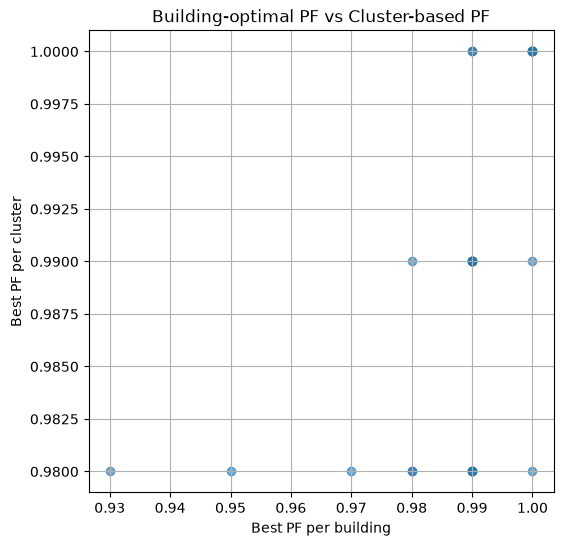

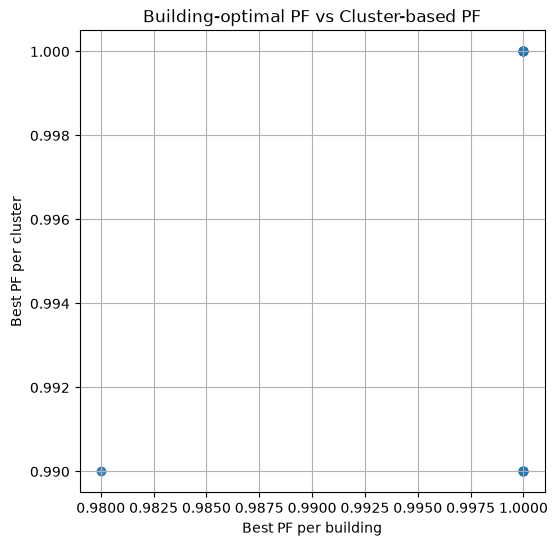

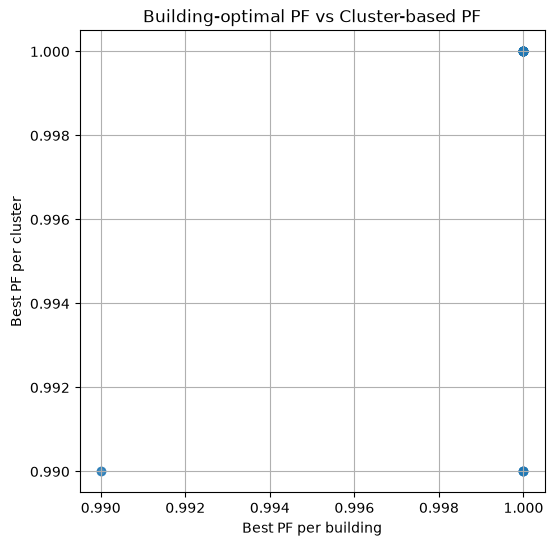

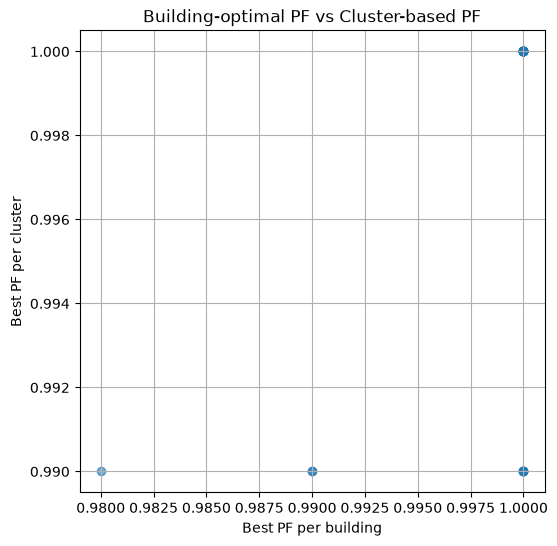

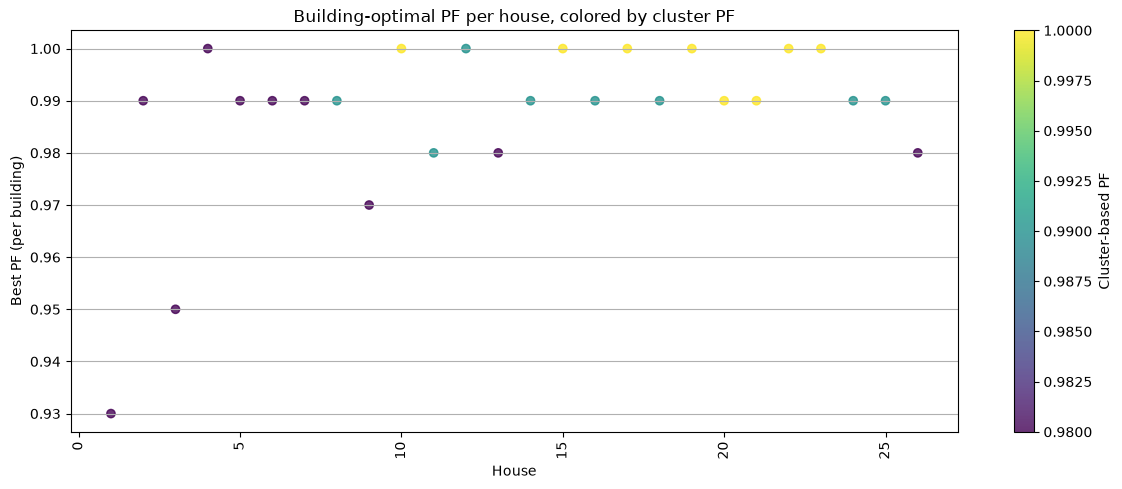

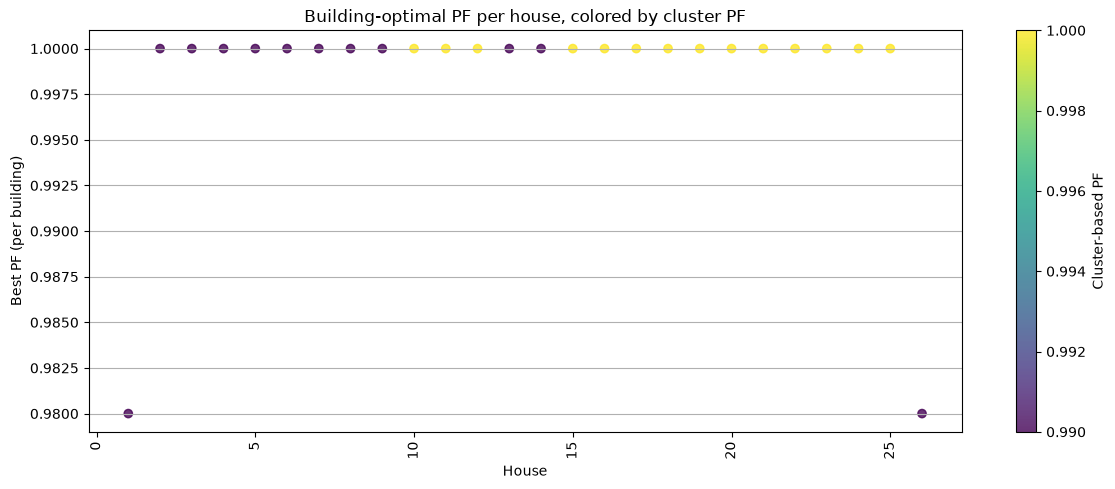

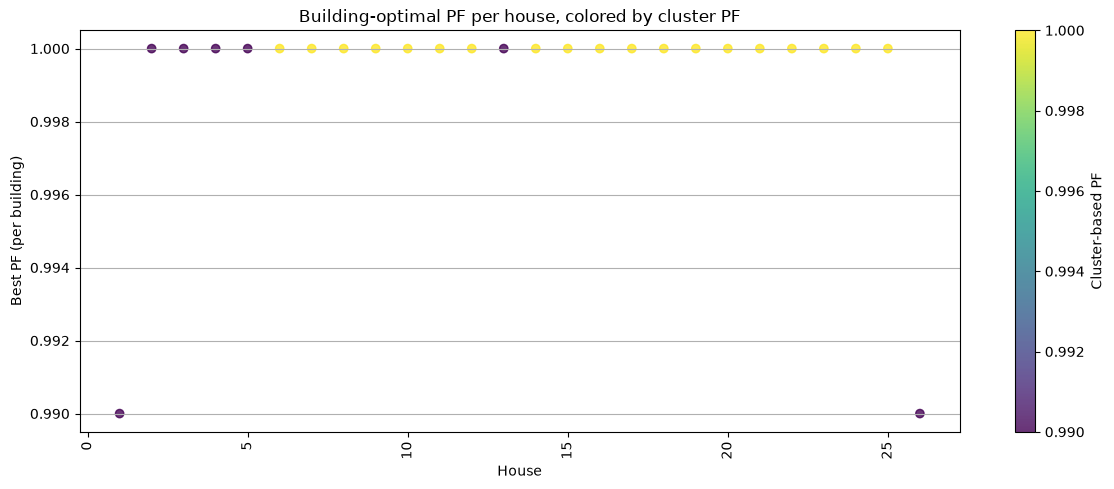

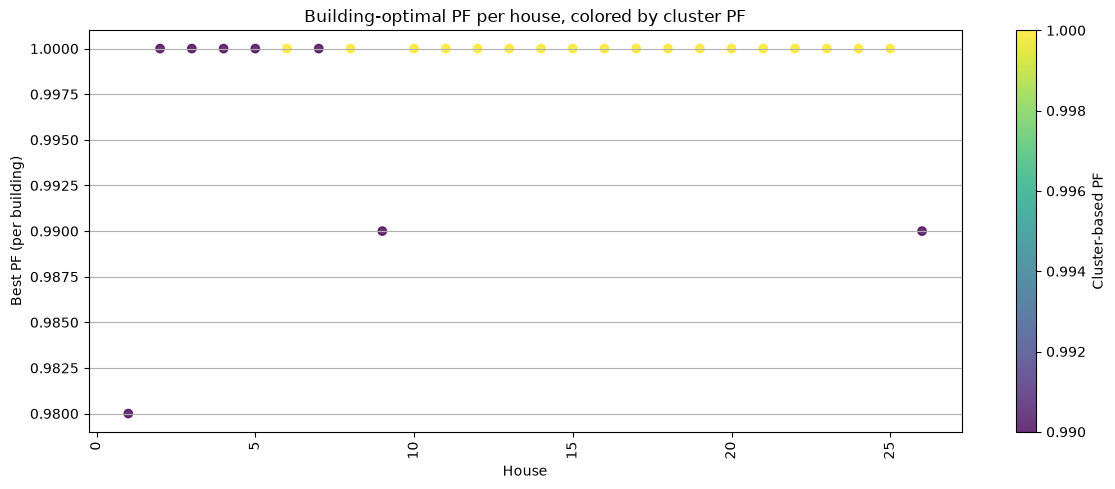

In [303]:
if input_period == "seasonal":
    vr.Optimal_PF_per_cluster(PF_list_summer, tub_PF_list_summer)
    vr.Optimal_PF_per_cluster(PF_list_fall, tub_PF_list_fall)
    vr.Optimal_PF_per_cluster(PF_list_winter, tub_PF_list_winter)
    vr.Optimal_PF_per_cluster(PF_list_spring, tub_PF_list_spring)
    vr.Optimal_PF_per_cluster_buildings(PF_list_summer, tub_PF_list_summer)
    vr.Optimal_PF_per_cluster_buildings(PF_list_fall, tub_PF_list_fall)
    vr.Optimal_PF_per_cluster_buildings(PF_list_winter, tub_PF_list_winter)
    vr.Optimal_PF_per_cluster_buildings(PF_list_spring, tub_PF_list_spring)
else:
    vr.Optimal_PF_per_cluster(PF_list, tub_PF_list)
    vr.Optimal_PF_per_cluster_buildings(PF_list, tub_PF_list)

Prints a table with statistics for each cluster.

In [304]:
if input_period == "seasonal":
    size_distribution_Summer = vr.size_distribution_per_cluster(Summer_data, PF_list_summer, houses)
    size_distribution_Winter = vr.size_distribution_per_cluster(Winter_data, PF_list_winter, houses)
    size_distribution_Fall = vr.size_distribution_per_cluster(Fall_data, PF_list_fall, houses)
    size_distribution_Spring = vr.size_distribution_per_cluster(Spring_data, PF_list_spring, houses)
    print(size_distribution_Summer)
    print(size_distribution_Winter)
    print(size_distribution_Fall)
    print(size_distribution_Spring)
else:
    size_distribution = vr.size_distribution_per_cluster(power_dict, PF_list, houses)
    print(size_distribution)

                             0.98         0.99         1.00
Count                   10.000000     8.000000     8.000000
Avg_size               690.229483  1133.058769  1211.129766
Median_PQ_correlation    0.627441     0.702401     0.721826
                             0.99        1.00
Count                    7.000000   19.000000
Avg_size               532.046229  739.466913
Median_PQ_correlation    0.296703    0.227009
                             0.99        1.00
Count                   12.000000   14.000000
Avg_size               528.733200  870.827398
Median_PQ_correlation    0.344519    0.460397
                             0.99        1.00
Count                    8.000000   18.000000
Avg_size               471.725492  723.734900
Median_PQ_correlation    0.400141    0.267691


In [305]:
if input_period == "seasonal":
    daily_summary_summer = vr.daily_stats_per_cluster(Summer_data, PF_list_summer, houses)
    compact_table_summer = vr.compact_daily_cluster_table(daily_summary_summer)
    print(compact_table_summer.round(3))
    daily_summary_fall = vr.daily_stats_per_cluster(Fall_data, PF_list_fall, houses)
    compact_table_fall = vr.compact_daily_cluster_table(daily_summary_fall)
    print(compact_table_fall.round(3))
    daily_summary_winter = vr.daily_stats_per_cluster(Winter_data, PF_list_winter, houses)
    compact_table_winter = vr.compact_daily_cluster_table(daily_summary_winter)
    print(compact_table_winter.round(3))
    daily_summary_spring = vr.daily_stats_per_cluster(Spring_data, PF_list_spring, houses)
    compact_table_spring = vr.compact_daily_cluster_table(daily_summary_spring)
    print(compact_table_spring.round(3))
else:
    daily_summary = vr.daily_stats_per_cluster(power_dict, PF_list, houses)
    compact_table = vr.compact_daily_cluster_table(daily_summary)
    print(compact_table.round(3))

         P_mean_wd  P_mean_we  P_day_night_wd  PF_mean_wd  PF_mean_we  \
Cluster                                                                 
0.98         0.320      0.293           1.152       0.974       0.975   
0.99         0.528      0.476           1.147       0.990       0.991   
1.00         0.568      0.499           1.283       0.991       0.991   

         PF_IQR_wd  PF_IQR_we  PF_min_we  
Cluster                                   
0.98         0.025      0.024      0.907  
0.99         0.010      0.010      0.957  
1.00         0.010      0.011      0.950  
         P_mean_wd  P_mean_we  P_day_night_wd  PF_mean_wd  PF_mean_we  \
Cluster                                                                 
0.99         0.245      0.235           1.291       0.986       0.987   
1.00         0.405      0.381           1.405       0.985       0.985   

         PF_IQR_wd  PF_IQR_we  PF_min_we  
Cluster                                   
0.99         0.017      0.016      0.916

Calculates the R2-metric for the clustering results.

In [306]:
if input_period == "seasonal":
    dict_list = [Summer_data, Fall_data, Winter_data, Spring_data]
    PF_serie_list = [PF_list_summer, PF_list_fall, PF_list_winter, PF_list_spring]
else:
    dict_list = [power_dict]
    PF_serie_list = [PF_list]

r2_score_basecase = vr.R2_metric_basecase(dict_list, best_PF)
print("r2_score_basecase:", r2_score_basecase)

r2_score = vr.R2_metric_calc(dict_list, PF_serie_list)
print("r2_score:", r2_score)

r2_score_basecase: -2.2465037416985467e-06
r2_score: 0.49405085232686285


Visualizes the error over time for the clustering results.

Key: `TUB` plots the theoretical upper bound vs. the basecase.
key: `Cluster` plot the clustering result error vs. the basecase.

26
26
26
26
26
26
26
26


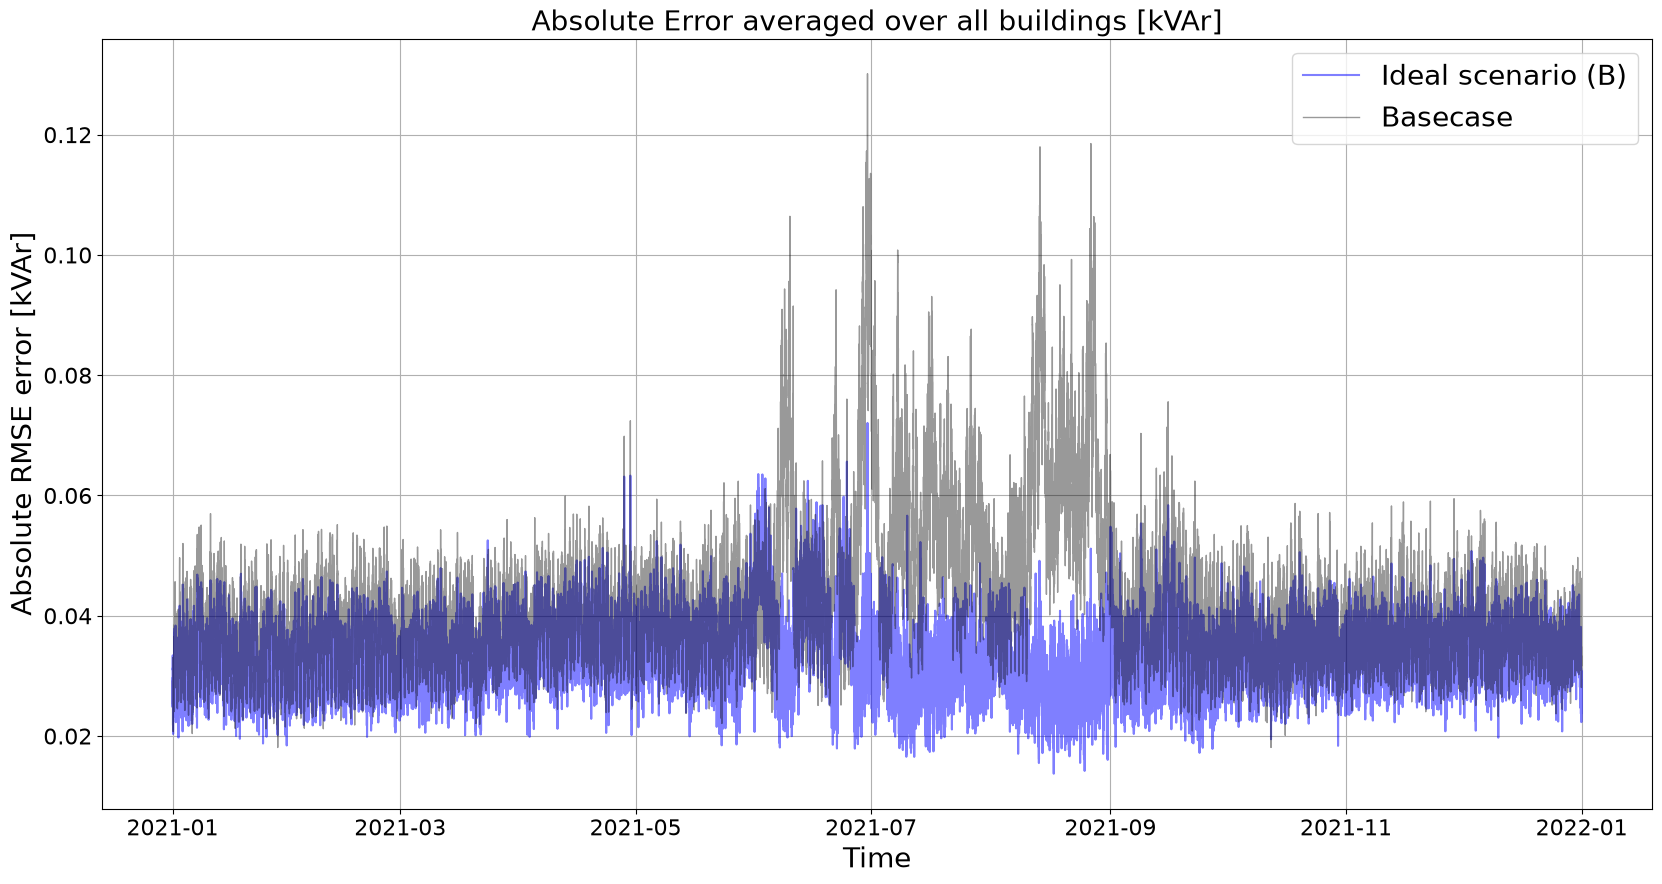

In [307]:
if input_period == "seasonal":
    error_over_time_summer = vr.error_timed_func(Summer_data, PF_list_summer, houses)
    error_over_time_fall = vr.error_timed_func(Fall_data, PF_list_fall, houses)
    error_over_time_winter = vr.error_timed_func(Winter_data, PF_list_winter, houses)
    error_over_time_spring = vr.error_timed_func(Spring_data, PF_list_spring, houses)
    tub_error_over_time_summer = vr.error_timed_func(Summer_data, tub_PF_list_summer, houses)
    tub_error_over_time_fall = vr.error_timed_func(Fall_data, tub_PF_list_fall, houses)
    tub_error_over_time_winter = vr.error_timed_func(Winter_data, tub_PF_list_winter, houses)
    tub_error_over_time_spring = vr.error_timed_func(Spring_data, tub_PF_list_spring, houses)
    basecase_error_over_time_summer = vr.Basecase_time(Summer_data, houses, best_PF)
    basecase_error_over_time_fall = vr.Basecase_time(Fall_data, houses, best_PF)
    basecase_error_over_time_winter = vr.Basecase_time(Winter_data, houses, best_PF)
    basecase_error_over_time_spring = vr.Basecase_time(Spring_data, houses, best_PF)
    error_over_time = pd.concat([error_over_time_summer, error_over_time_fall, error_over_time_winter, error_over_time_spring]).sort_index()
    error_over_time_best = pd.concat([tub_error_over_time_summer, tub_error_over_time_fall, tub_error_over_time_winter, tub_error_over_time_spring]).sort_index()
    basecase_error = pd.concat([basecase_error_over_time_summer, basecase_error_over_time_fall, basecase_error_over_time_winter, basecase_error_over_time_spring]).sort_index()
else:
    error_over_time = vr.error_timed_func(power_dict, PF_list, houses).sort_index()
    error_over_time_best = vr.error_timed_func(power_dict, tub_PF_list, houses).sort_index()
    basecase_error = vr.Basecase_time(power_dict, houses, best_PF).sort_index()

vr.error_over_time_viz(error_over_time, basecase_error, error_over_time_best, "TUB")

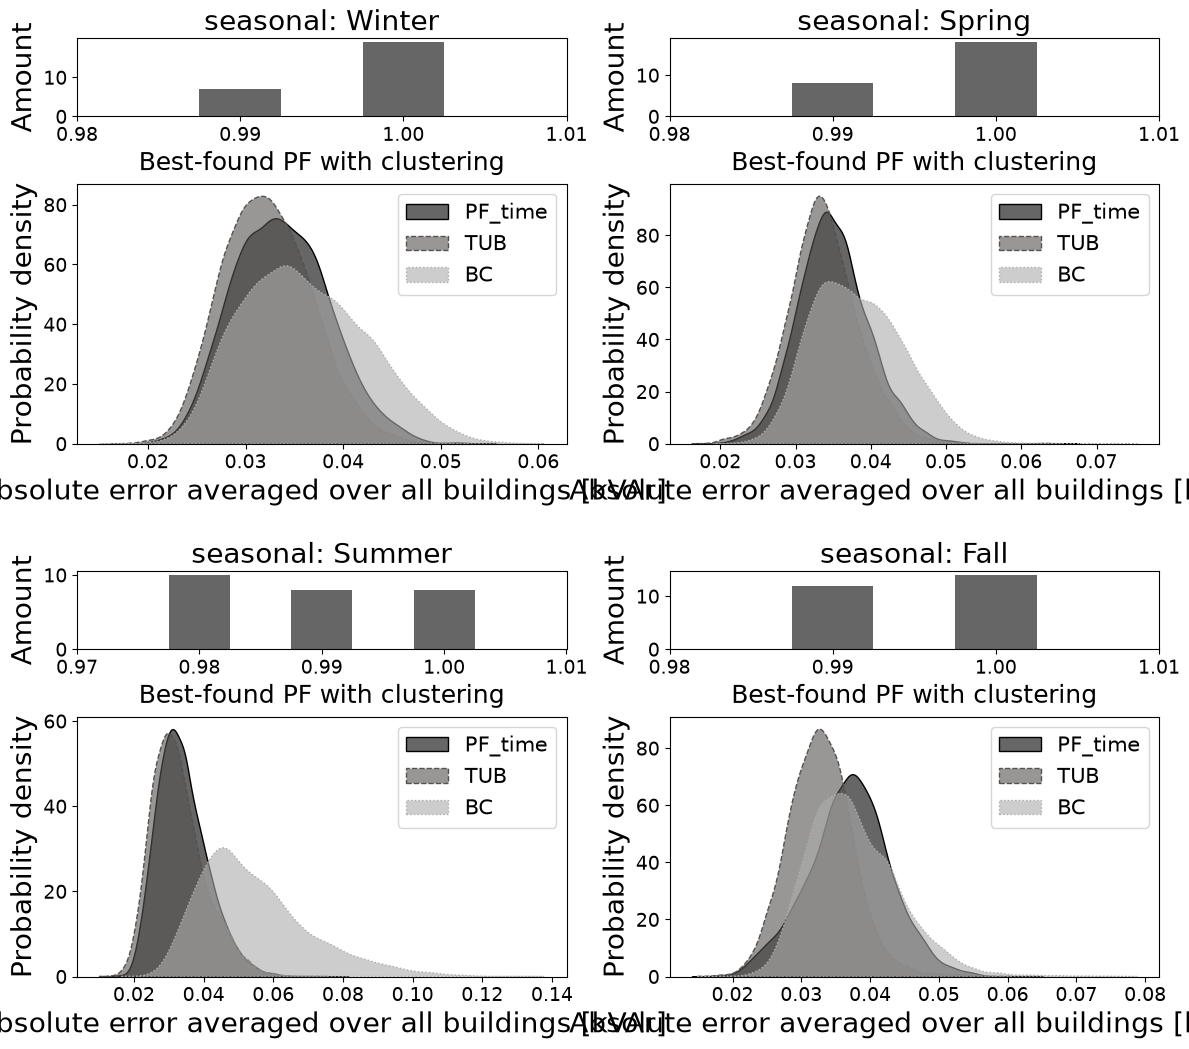

In [308]:
if input_period == "seasonal":
    size_distribution_list = [size_distribution_Summer, size_distribution_Fall, size_distribution_Winter, size_distribution_Spring]
    error_over_time_list = [error_over_time_summer, error_over_time_fall, error_over_time_winter, error_over_time_spring]
    error_over_time_best_list = [tub_error_over_time_summer, tub_error_over_time_fall, tub_error_over_time_winter, tub_error_over_time_spring]
    error_over_time_basecase_list = [basecase_error_over_time_summer, basecase_error_over_time_fall, basecase_error_over_time_winter, basecase_error_over_time_spring]
else:
    size_distribution_list = [size_distribution]
    error_over_time_list = [error_over_time]
    error_over_time_best_list = [error_over_time_best]
    error_over_time_basecase_list = [basecase_error]

vr.distribution_error_plot(size_distribution_list, error_over_time_list, error_over_time_basecase_list, error_over_time_best_list, input_period, "PF_time")